## Modelado del sistema con NARX (5 retardos)

En este análisis se emplea un modelo NARX con 5 retardos, lo que implica un mayor nivel de memoria del sistema. Se comparan un modelo lineal y un modelo no lineal (MLP) para evaluar si el aumento de información mejora la capacidad predictiva.

El objetivo es analizar si el incremento de retardos permite capturar mejor la dinámica del sistema o si introduce problemas como sobreajuste.

Shape: (29988, 29)
MSE lineal: 0.010337162093504203
MSE MLP: 0.009475379628134441


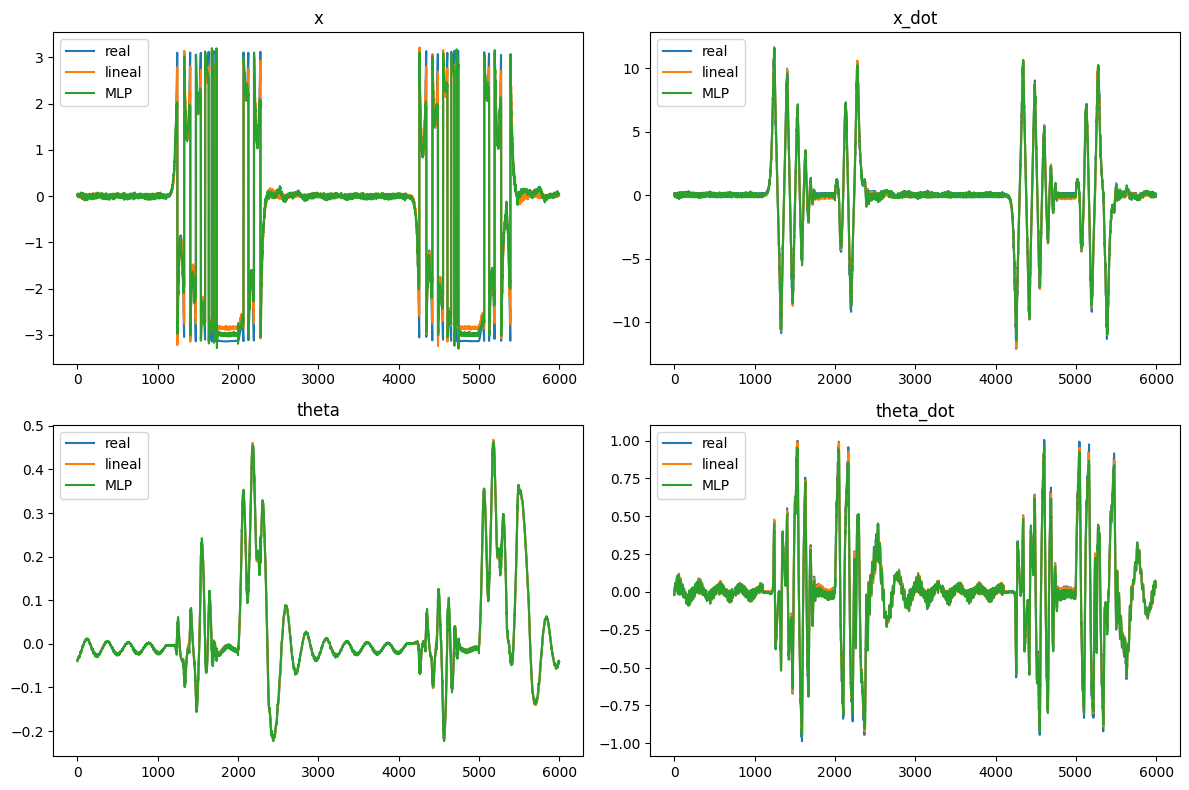

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

# =========================
# CARGA Y LIMPIEZA
# =========================
df = pd.read_csv(r"C:\Users\alber\OneDrive\Desktop\control automático\control-autom-tico\Data\real\dataset_5_total.csv")

df = df[df["x_k"] != "x_k"]
df = df.apply(pd.to_numeric)

print("Shape:", df.shape)

# =========================
# SEPARAR X e Y
# =========================
Y = df[["x_k", "x_dot_k", "theta_k", "theta_dot_k"]].values
X = df.drop(columns=["x_k", "x_dot_k", "theta_k", "theta_dot_k"]).values

# =========================
# SPLIT
# =========================
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
Y_train, Y_test = Y[:split], Y[split:]

# =========================
# NORMALIZACIÓN
# =========================
sx = StandardScaler()
sy = StandardScaler()

X_train = sx.fit_transform(X_train)
X_test = sx.transform(X_test)

Y_train = sy.fit_transform(Y_train)
Y_test = sy.transform(Y_test)

# =========================
# MODELO LINEAL
# =========================
lin = LinearRegression()
lin.fit(X_train, Y_train)

Y_pred_lin = lin.predict(X_test)
mse_lin = mean_squared_error(Y_test, Y_pred_lin)

print("MSE lineal:", mse_lin)

# =========================
# MODELO MLP
# =========================
mlp = MLPRegressor(hidden_layer_sizes=(32,32), max_iter=500, random_state=42)
mlp.fit(X_train, Y_train)

Y_pred_mlp = mlp.predict(X_test)
mse_mlp = mean_squared_error(Y_test, Y_pred_mlp)

print("MSE MLP:", mse_mlp)

# =========================
# DESNORMALIZAR
# =========================
Y_test_real = sy.inverse_transform(Y_test)
Y_lin_real = sy.inverse_transform(Y_pred_lin)
Y_mlp_real = sy.inverse_transform(Y_pred_mlp)

# =========================
# PLOT
# =========================
labels = ["x", "x_dot", "theta", "theta_dot"]

plt.figure(figsize=(12,8))

for i in range(4):
    plt.subplot(2,2,i+1)
    plt.plot(Y_test_real[:,i], label="real")
    plt.plot(Y_lin_real[:,i], label="lineal")
    plt.plot(Y_mlp_real[:,i], label="MLP")
    plt.title(labels[i])
    plt.legend()

plt.tight_layout()
plt.show()

Dataset cargado — shape: (29988, 29)

  MSE GLOBAL  |  Baseline: 0.065153
              |  Lineal:   0.057967  (+11.0%)
              |  MLP:      0.042357  (+35.0%)



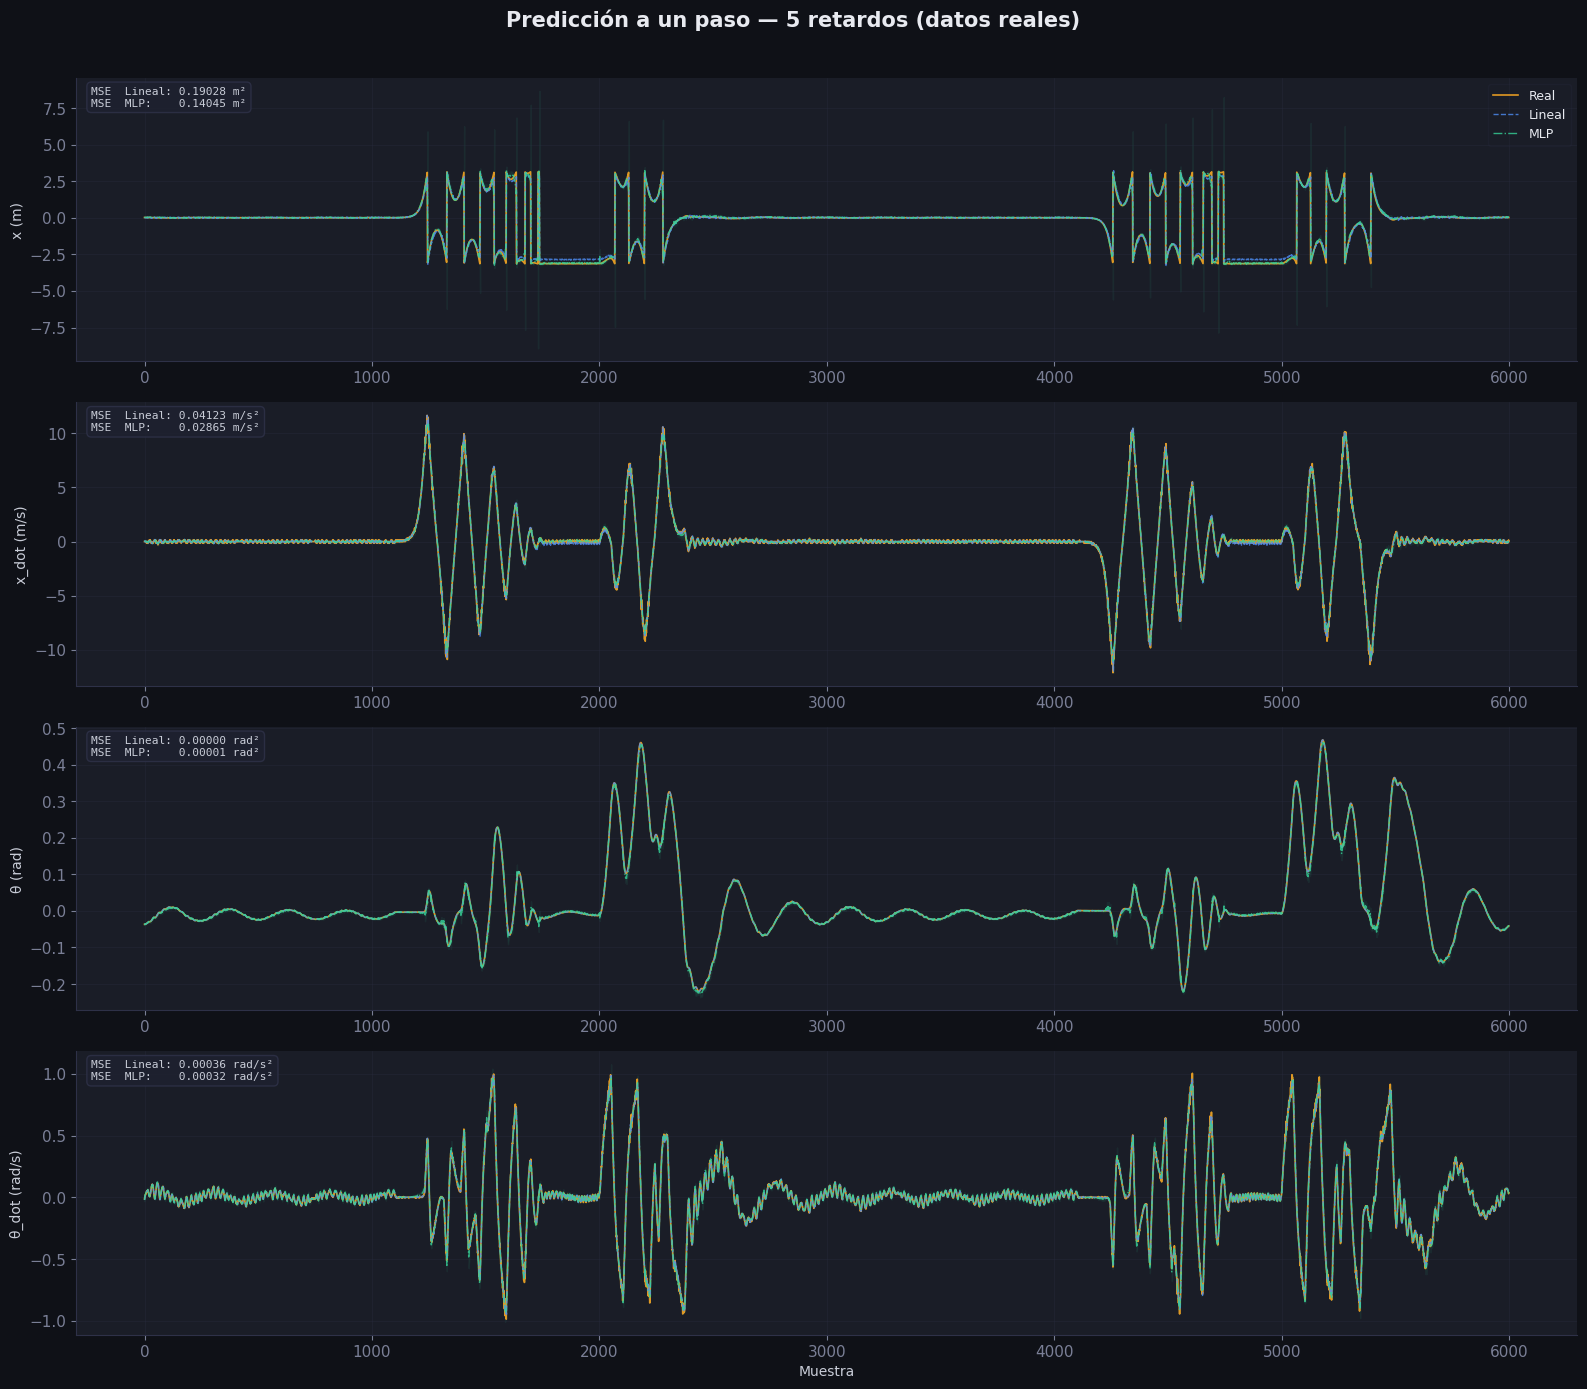

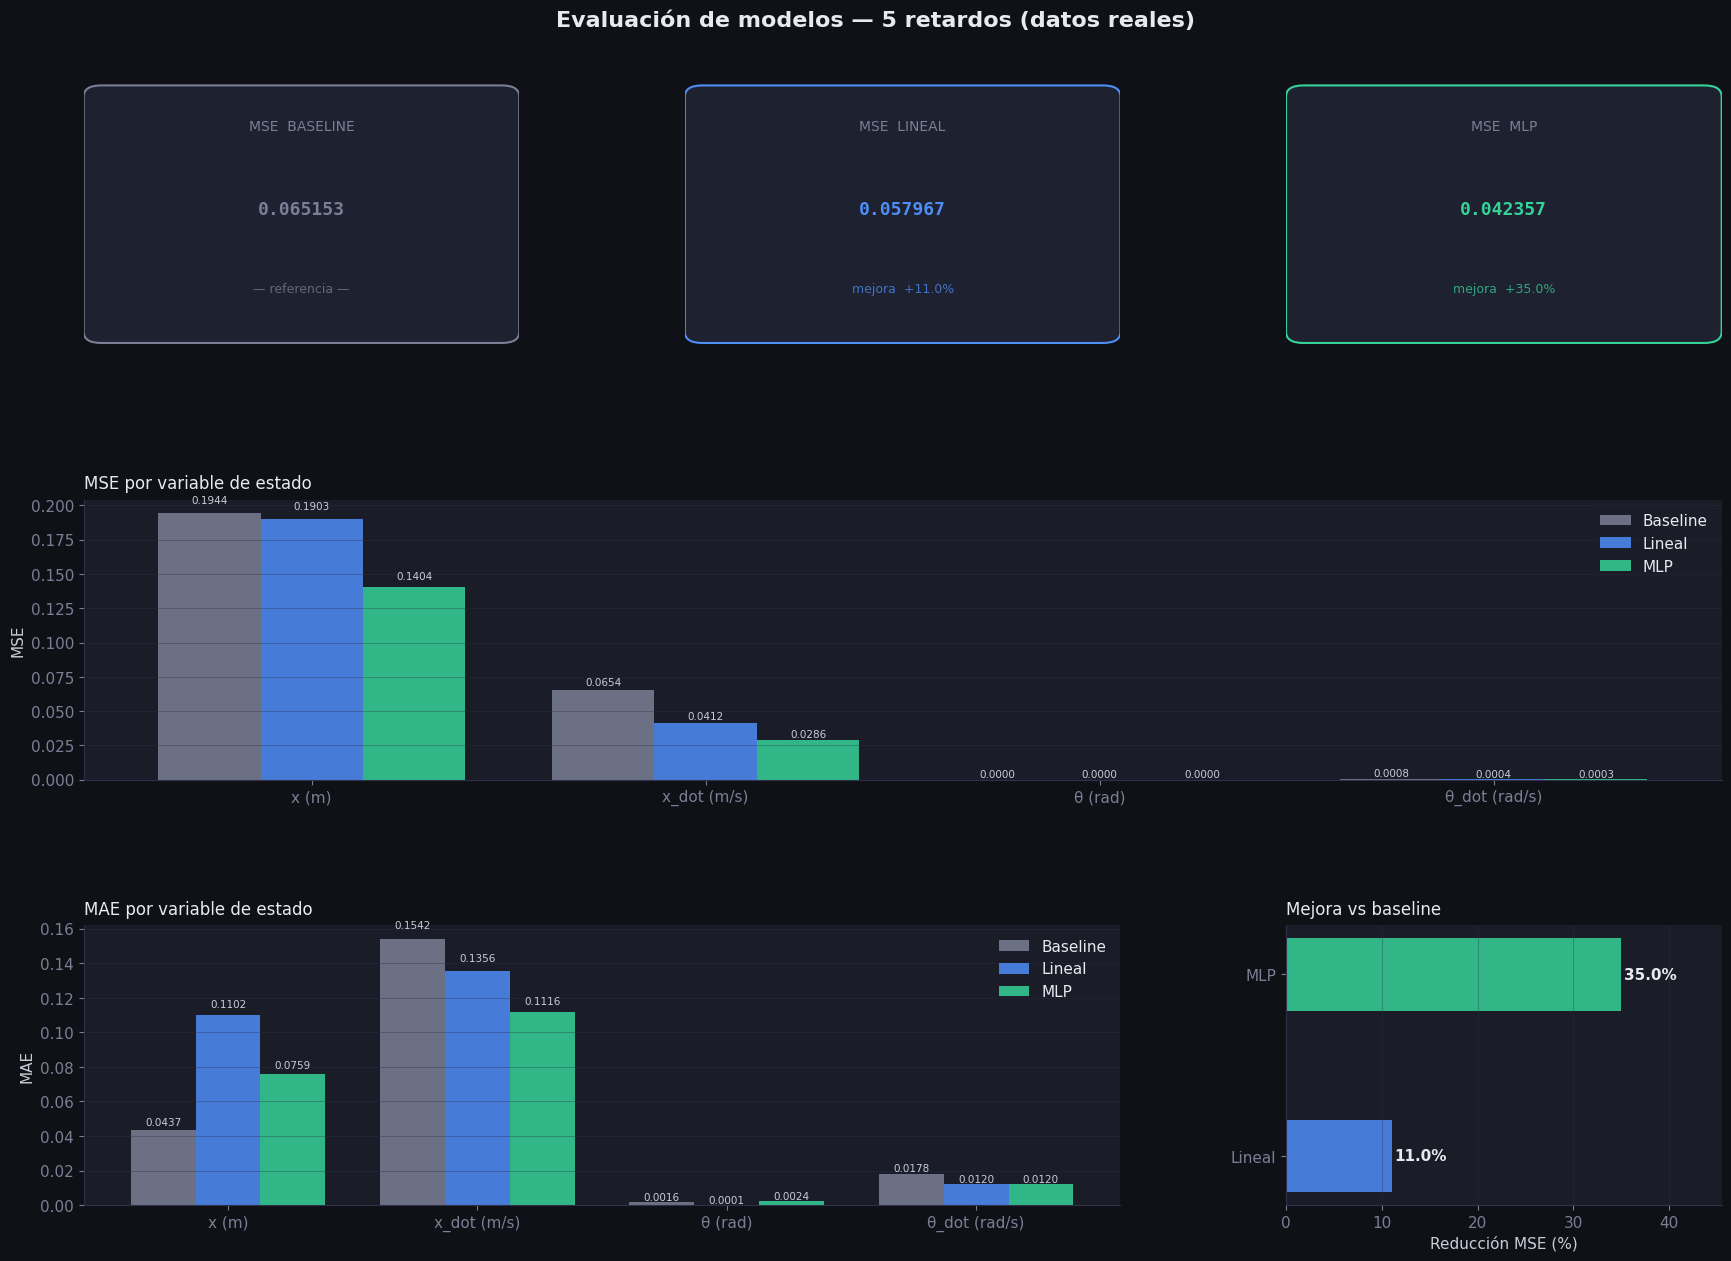

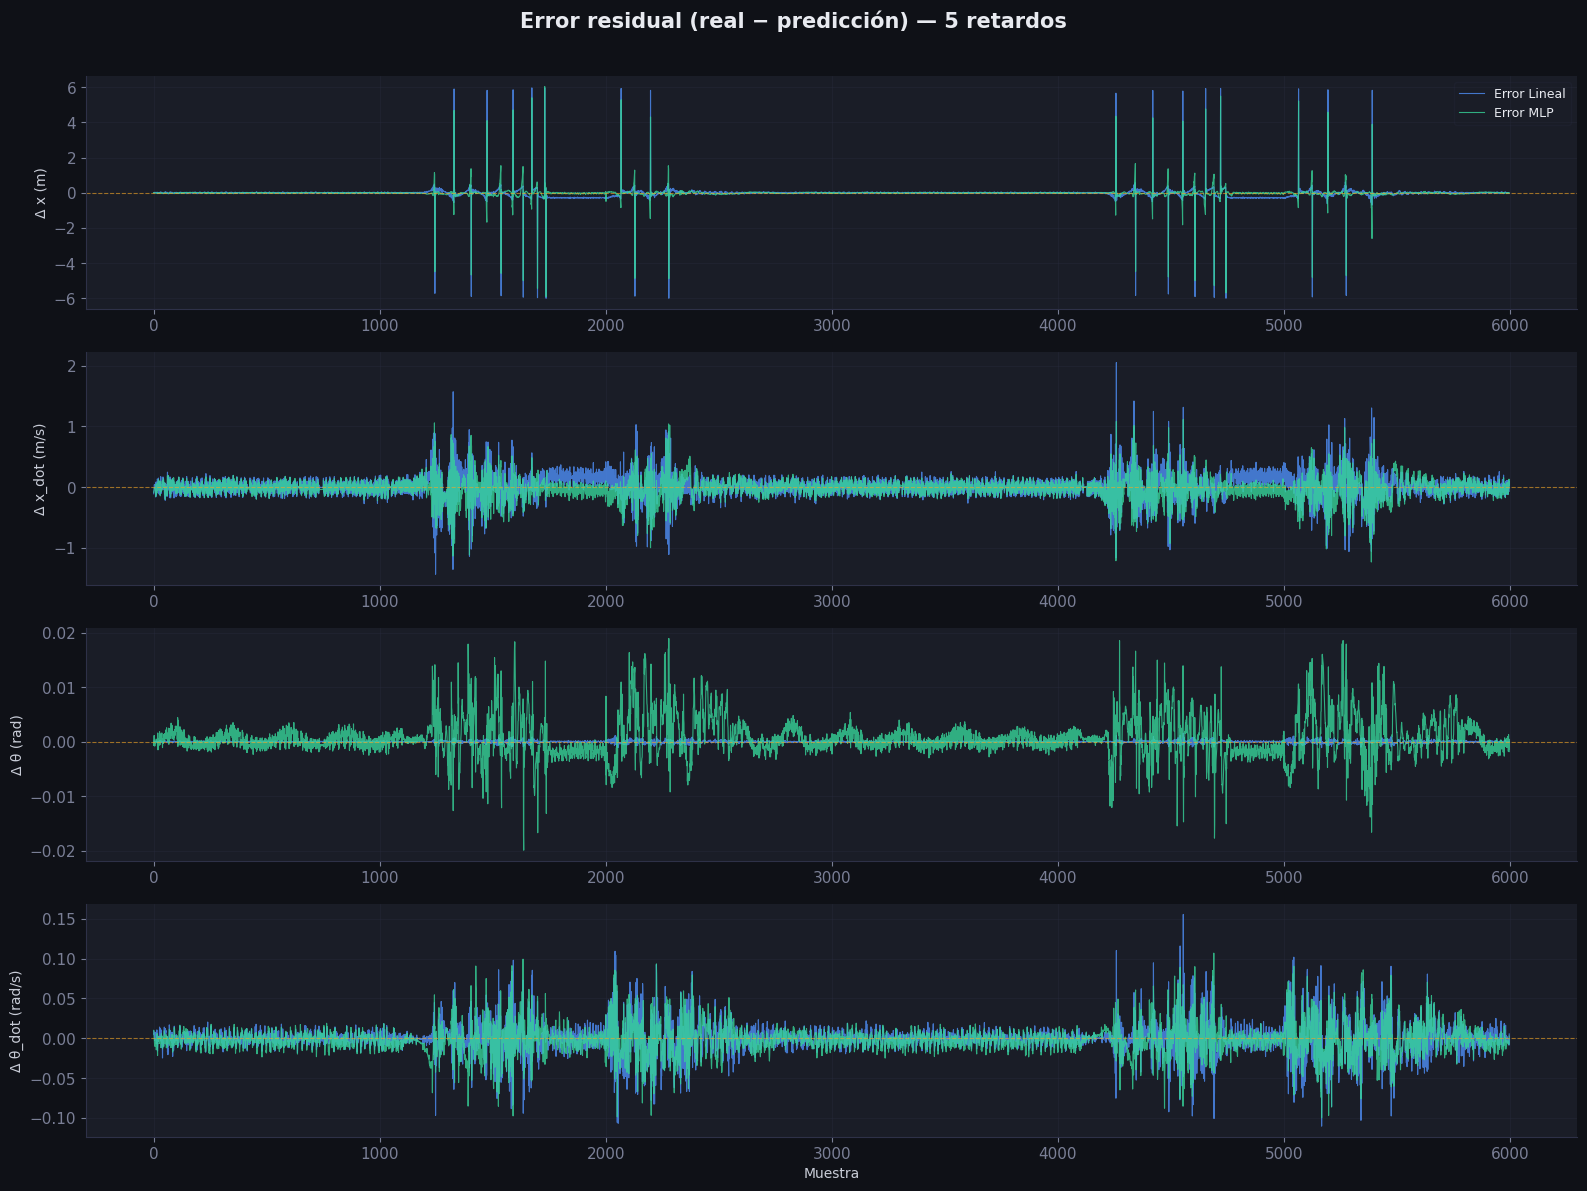


✓ Figuras guardadas:
  · predicciones_5retardos.png
  · metricas_5retardos.png
  · residuos_5retardos.png


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# ── Estilo global ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#2e3148',
    'axes.labelcolor':  '#c9cdd8',
    'xtick.color':      '#7a7f96',
    'ytick.color':      '#7a7f96',
    'text.color':       '#e8eaf0',
    'grid.color':       '#2e3148',
    'grid.linewidth':   0.6,
    'font.family':      'DejaVu Sans',
    'font.size':        11,
})

COLORS = {
    'real':     '#f6a623',
    'lineal':   '#4e8ef7',
    'mlp':      '#36d399',
    'baseline': '#7a7f96',
    'bg_card':  '#1e2130',
    'border':   '#2e3148',
}

LABELS      = ["x (m)", "x_dot (m/s)", "θ (rad)", "θ_dot (rad/s)"]
UNITS       = ["m",     "m/s",         "rad",      "rad/s"]

# ══════════════════════════════════════════════════════════════════════════════
# 1 · CARGA Y LIMPIEZA
# ══════════════════════════════════════════════════════════════════════════════
df = pd.read_csv(r"C:\Users\alber\OneDrive\Desktop\control automático\control-autom-tico\Data\real\dataset_5_total.csv")
df = df[df["x_k"] != "x_k"]
df = df.apply(pd.to_numeric)
print(f"Dataset cargado — shape: {df.shape}")

# ══════════════════════════════════════════════════════════════════════════════
# 2 · SEPARAR X e Y
# ══════════════════════════════════════════════════════════════════════════════
output_cols = ["x_k", "x_dot_k", "theta_k", "theta_dot_k"]
Y = df[output_cols].values
X = df.drop(columns=output_cols).values

# ══════════════════════════════════════════════════════════════════════════════
# 3 · SPLIT TEMPORAL (80/20)
# ══════════════════════════════════════════════════════════════════════════════
split   = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
Y_train, Y_test = Y[:split], Y[split:]

# ══════════════════════════════════════════════════════════════════════════════
# 4 · NORMALIZACIÓN
# ══════════════════════════════════════════════════════════════════════════════
sx, sy = StandardScaler(), StandardScaler()
X_train_s = sx.fit_transform(X_train)
X_test_s  = sx.transform(X_test)
Y_train_s = sy.fit_transform(Y_train)
Y_test_s  = sy.transform(Y_test)

# ══════════════════════════════════════════════════════════════════════════════
# 5 · MODELOS
# ══════════════════════════════════════════════════════════════════════════════
lin = LinearRegression()
lin.fit(X_train_s, Y_train_s)
Y_pred_lin_s = lin.predict(X_test_s)

mlp = MLPRegressor(hidden_layer_sizes=(64, 64), max_iter=500,
                   random_state=42, early_stopping=True, validation_fraction=0.1)
mlp.fit(X_train_s, Y_train_s)
Y_pred_mlp_s = mlp.predict(X_test_s)

# ══════════════════════════════════════════════════════════════════════════════
# 6 · DESNORMALIZAR
# ══════════════════════════════════════════════════════════════════════════════
Y_test_real = sy.inverse_transform(Y_test_s)
Y_lin_real  = sy.inverse_transform(Y_pred_lin_s)
Y_mlp_real  = sy.inverse_transform(Y_pred_mlp_s)

# ── Baseline (persistencia) ───────────────────────────────────────────────────
Y_pred_base       = np.zeros_like(Y_test_real)
Y_pred_base[1:]   = Y_test_real[:-1]
Y_pred_base_valid = Y_pred_base[1:]
Y_test_base_valid = Y_test_real[1:]

# ── Métricas globales ─────────────────────────────────────────────────────────
mse_base = mean_squared_error(Y_test_base_valid, Y_pred_base_valid)
mse_lin  = mean_squared_error(Y_test_real, Y_lin_real)
mse_mlp  = mean_squared_error(Y_test_real, Y_mlp_real)

mejora_lin = (mse_base - mse_lin) / mse_base * 100
mejora_mlp = (mse_base - mse_mlp) / mse_base * 100

print(f"\n{'='*45}")
print(f"  MSE GLOBAL  |  Baseline: {mse_base:.6f}")
print(f"              |  Lineal:   {mse_lin:.6f}  ({mejora_lin:+.1f}%)")
print(f"              |  MLP:      {mse_mlp:.6f}  ({mejora_mlp:+.1f}%)")
print(f"{'='*45}\n")

# ── Métricas por variable ─────────────────────────────────────────────────────
mse_vars = {
    'base': [mean_squared_error(Y_test_base_valid[:, i], Y_pred_base_valid[:, i]) for i in range(4)],
    'lin':  [mean_squared_error(Y_test_real[:, i], Y_lin_real[:, i])              for i in range(4)],
    'mlp':  [mean_squared_error(Y_test_real[:, i], Y_mlp_real[:, i])              for i in range(4)],
}
mae_vars = {
    'base': [mean_absolute_error(Y_test_base_valid[:, i], Y_pred_base_valid[:, i]) for i in range(4)],
    'lin':  [mean_absolute_error(Y_test_real[:, i], Y_lin_real[:, i])              for i in range(4)],
    'mlp':  [mean_absolute_error(Y_test_real[:, i], Y_mlp_real[:, i])              for i in range(4)],
}

# ══════════════════════════════════════════════════════════════════════════════
# 7 · FIGURA 1 — PREDICCIONES POR VARIABLE
# ══════════════════════════════════════════════════════════════════════════════
t = np.arange(len(Y_test_real))

fig1, axes = plt.subplots(4, 1, figsize=(16, 14), facecolor='#0f1117')
fig1.suptitle('Predicción a un paso — 5 retardos (datos reales)',
              fontsize=15, fontweight='bold', color='#e8eaf0', y=0.99)

for i, ax in enumerate(axes):
    ax.set_facecolor('#1a1d27')
    ax.plot(t, Y_test_real[:, i], color=COLORS['real'],    lw=1.2, label='Real',   alpha=0.9)
    ax.plot(t, Y_lin_real[:, i],  color=COLORS['lineal'],  lw=1.0, label='Lineal', alpha=0.8, linestyle='--')
    ax.plot(t, Y_mlp_real[:, i],  color=COLORS['mlp'],     lw=1.0, label='MLP',    alpha=0.8, linestyle='-.')

    # Banda de error MLP
    err = np.abs(Y_test_real[:, i] - Y_mlp_real[:, i])
    ax.fill_between(t,
                    Y_mlp_real[:, i] - err,
                    Y_mlp_real[:, i] + err,
                    color=COLORS['mlp'], alpha=0.07)

    # Anotación MSE en la esquina
    txt = (f"MSE  Lineal: {mse_vars['lin'][i]:.5f} {UNITS[i]}²\n"
           f"MSE  MLP:    {mse_vars['mlp'][i]:.5f} {UNITS[i]}²")
    ax.text(0.01, 0.97, txt, transform=ax.transAxes,
            fontsize=8, va='top', color='#c9cdd8',
            fontfamily='monospace',
            bbox=dict(facecolor='#1e2130', edgecolor='#2e3148',
                      boxstyle='round,pad=0.4', alpha=0.85))

    ax.set_ylabel(LABELS[i], fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)
    if i == 0:
        ax.legend(loc='upper right', framealpha=0.2,
                  edgecolor=COLORS['border'], fontsize=9)
    if i == 3:
        ax.set_xlabel('Muestra', fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig('predicciones_5retardos.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# 8 · FIGURA 2 — MÉTRICAS (tarjetas + barras)
# ══════════════════════════════════════════════════════════════════════════════
def draw_card(ax, title, value, subtitle, color):
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off')
    ax.add_patch(FancyBboxPatch((0.04, 0.08), 0.92, 0.84,
                                boxstyle="round,pad=0.04",
                                facecolor=COLORS['bg_card'],
                                edgecolor=color, linewidth=1.5))
    ax.text(0.5, 0.80, title,            ha='center', fontsize=10,  color='#7a7f96')
    ax.text(0.5, 0.50, f'{value:.6f}',   ha='center', fontsize=13,  color=color,
            fontweight='bold', fontfamily='monospace')
    ax.text(0.5, 0.22, subtitle,         ha='center', fontsize=9,   color=color, alpha=0.75)

fig2 = plt.figure(figsize=(18, 13), facecolor='#0f1117')
fig2.suptitle('Evaluación de modelos — 5 retardos (datos reales)',
              fontsize=16, fontweight='bold', color='#e8eaf0', y=0.98)

gs = gridspec.GridSpec(3, 3, figure=fig2, hspace=0.52, wspace=0.38,
                       top=0.93, bottom=0.06, left=0.06, right=0.97)

draw_card(fig2.add_subplot(gs[0, 0]), 'MSE  BASELINE', mse_base,
          '— referencia —',                COLORS['baseline'])
draw_card(fig2.add_subplot(gs[0, 1]), 'MSE  LINEAL',   mse_lin,
          f'mejora  {mejora_lin:+.1f}%',   COLORS['lineal'])
draw_card(fig2.add_subplot(gs[0, 2]), 'MSE  MLP',      mse_mlp,
          f'mejora  {mejora_mlp:+.1f}%',   COLORS['mlp'])

# Barras MSE por variable
ax_mse = fig2.add_subplot(gs[1, :])
ax_mse.set_title('MSE por variable de estado', fontsize=12, pad=8, loc='left')
x, w = np.arange(4), 0.26
for bars, key, color, lbl in [
    (ax_mse.bar(x - w, mse_vars['base'], w, color=COLORS['baseline'], alpha=0.85), 'base', COLORS['baseline'], 'Baseline'),
    (ax_mse.bar(x,     mse_vars['lin'],  w, color=COLORS['lineal'],   alpha=0.85), 'lin',  COLORS['lineal'],   'Lineal'),
    (ax_mse.bar(x + w, mse_vars['mlp'],  w, color=COLORS['mlp'],      alpha=0.85), 'mlp',  COLORS['mlp'],      'MLP'),
]:
    for bar in bars:
        h = bar.get_height()
        ax_mse.text(bar.get_x() + bar.get_width() / 2, h * 1.03,
                    f'{h:.4f}', ha='center', va='bottom', fontsize=7.5, color='#c9cdd8')
ax_mse.set_xticks(x); ax_mse.set_xticklabels(LABELS)
ax_mse.set_ylabel('MSE'); ax_mse.grid(axis='y', alpha=0.4)
ax_mse.legend(['Baseline','Lineal','MLP'], framealpha=0.15, edgecolor=COLORS['border'])
ax_mse.spines[['top','right']].set_visible(False)

# Barras MAE por variable
ax_mae = fig2.add_subplot(gs[2, :2])
ax_mae.set_title('MAE por variable de estado', fontsize=12, pad=8, loc='left')
for bars, key, color in [
    (ax_mae.bar(x - w, mae_vars['base'], w, color=COLORS['baseline'], alpha=0.85), 'base', COLORS['baseline']),
    (ax_mae.bar(x,     mae_vars['lin'],  w, color=COLORS['lineal'],   alpha=0.85), 'lin',  COLORS['lineal']),
    (ax_mae.bar(x + w, mae_vars['mlp'],  w, color=COLORS['mlp'],      alpha=0.85), 'mlp',  COLORS['mlp']),
]:
    for bar in bars:
        h = bar.get_height()
        ax_mae.text(bar.get_x() + bar.get_width() / 2, h * 1.03,
                    f'{h:.4f}', ha='center', va='bottom', fontsize=7.5, color='#c9cdd8')
ax_mae.set_xticks(x); ax_mae.set_xticklabels(LABELS)
ax_mae.set_ylabel('MAE'); ax_mae.grid(axis='y', alpha=0.4)
ax_mae.legend(['Baseline','Lineal','MLP'], framealpha=0.15, edgecolor=COLORS['border'])
ax_mae.spines[['top','right']].set_visible(False)

# Mejora % horizontal
ax_mej = fig2.add_subplot(gs[2, 2])
ax_mej.set_title('Mejora vs baseline', fontsize=12, pad=8, loc='left')
bars_mej = ax_mej.barh(['Lineal','MLP'], [mejora_lin, mejora_mlp],
                        color=[COLORS['lineal'], COLORS['mlp']], alpha=0.85, height=0.4)
for bar, val in zip(bars_mej, [mejora_lin, mejora_mlp]):
    ax_mej.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}%', va='center', fontsize=11,
                color='#e8eaf0', fontweight='bold')
ax_mej.set_xlabel('Reducción MSE (%)')
ax_mej.grid(axis='x', alpha=0.4)
ax_mej.spines[['top','right']].set_visible(False)
ax_mej.set_xlim(0, max(mejora_lin, mejora_mlp) * 1.3)

plt.savefig('metricas_5retardos.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# 9 · FIGURA 3 — ERROR RESIDUAL POR VARIABLE
# ══════════════════════════════════════════════════════════════════════════════
fig3, axes3 = plt.subplots(4, 1, figsize=(16, 12), facecolor='#0f1117')
fig3.suptitle('Error residual (real − predicción) — 5 retardos',
              fontsize=15, fontweight='bold', color='#e8eaf0', y=0.99)

for i, ax in enumerate(axes3):
    ax.set_facecolor('#1a1d27')
    err_lin = Y_test_real[:, i] - Y_lin_real[:, i]
    err_mlp = Y_test_real[:, i] - Y_mlp_real[:, i]
    ax.plot(t, err_lin, color=COLORS['lineal'], lw=0.8, alpha=0.8, label='Error Lineal')
    ax.plot(t, err_mlp, color=COLORS['mlp'],    lw=0.8, alpha=0.8, label='Error MLP')
    ax.axhline(0, color='#f6a623', lw=0.8, linestyle='--', alpha=0.6)
    ax.set_ylabel(f'Δ {LABELS[i]}', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.spines[['top','right']].set_visible(False)
    if i == 0:
        ax.legend(loc='upper right', framealpha=0.2,
                  edgecolor=COLORS['border'], fontsize=9)
    if i == 3:
        ax.set_xlabel('Muestra', fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig('residuos_5retardos.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()

print("\n✓ Figuras guardadas:")
print("  · predicciones_5retardos.png")
print("  · metricas_5retardos.png")
print("  · residuos_5retardos.png")